In [1]:
import os
from core.brailleimages import read_cleaned, HOGTransformer, GaussianTransformer, SobelTransformer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

raw_folderpath = "../data/raw/braille-character-dataset/Braille Dataset/Braille Dataset"
processed_folderpath = "../data/processed/braille-character-dataset"

df = read_cleaned(os.path.join(processed_folderpath, 'braille.csv'))

In [2]:
%load_ext autoreload

%autoreload 2

## Gridsearch

In [295]:
# parameter search for poly kernel

features = df.iloc[:, :-3]
target = df.loc[:, 'letter']

hogify = HOGTransformer(orientations=8, pixels_per_cell=(9, 9))
pipe_hog_std = Pipeline([('hog', hogify),('std', StandardScaler())])

features_hog_std = pipe_hog_std.fit_transform(features)
X_train, X_test, y_train, y_test = train_test_split(features_hog_std, target, stratify=target, test_size=.2, random_state=1)
clf = SVC(kernel='poly', random_state=42)

param_grid={
    'degree': [2, 3, 4, 5, 6],
    'gamma': ['scale', .05, .08, .1, ],
    'C':[1e-5, 5e-4, .001, .002, 1],
    'coef0': [-1, 0, 5, 8, 10]
}

param_search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='accuracy', cv=5, verbose=4)
param_search.fit(X_train, y_train)
print(param_search.best_score_)
print(param_search.best_params_)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV 1/5] END C=1e-05, coef0=-1, degree=2, gamma=scale;, score=0.004 total time=   0.1s
[CV 2/5] END C=1e-05, coef0=-1, degree=2, gamma=scale;, score=0.004 total time=   0.1s
[CV 3/5] END C=1e-05, coef0=-1, degree=2, gamma=scale;, score=0.004 total time=   0.1s
[CV 4/5] END C=1e-05, coef0=-1, degree=2, gamma=scale;, score=0.000 total time=   0.1s
[CV 5/5] END C=1e-05, coef0=-1, degree=2, gamma=scale;, score=0.000 total time=   0.1s
[CV 1/5] END C=1e-05, coef0=-1, degree=2, gamma=0.05;, score=0.008 total time=   0.1s
[CV 2/5] END C=1e-05, coef0=-1, degree=2, gamma=0.05;, score=0.004 total time=   0.1s
[CV 3/5] END C=1e-05, coef0=-1, degree=2, gamma=0.05;, score=0.004 total time=   0.1s
[CV 4/5] END C=1e-05, coef0=-1, degree=2, gamma=0.05;, score=0.004 total time=   0.1s
[CV 5/5] END C=1e-05, coef0=-1, degree=2, gamma=0.05;, score=0.000 total time=   0.1s
[CV 1/5] END C=1e-05, coef0=-1, degree=2, gamma=0.08;, score=0.036 tota

In [ ]:
# parameter search for rbf kernel

features = df.iloc[:, :-3]
target = df.loc[:, 'letter']

hogify = HOGTransformer(orientations=6, pixels_per_cell=(9, 9))
pipe_hog_std = Pipeline([('hog', hogify),('std', StandardScaler())])

features_hog_std = pipe_hog_std.fit_transform(features)
X_train, X_test, y_train, y_test = train_test_split(features_hog_std, target, stratify=target, test_size=.2, random_state=1)
clf = SVC(kernel='rbf', random_state=42)

param_grid={
    'gamma': ['scale', 1e-5, 1e-3, .1, 1, 10, 100],
    'C':[.1, 1, 5, 10, 20, 50, 100]
}

param_search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='accuracy', cv=5, verbose=4)
param_search.fit(X_train, y_train)
print(param_search.best_score_)
print(param_search.best_params_)

Fitting 5 folds for each of 49 candidates, totalling 245 fits
[CV 1/5] END ................C=0.1, gamma=scale;, score=0.532 total time=   0.2s
[CV 2/5] END ................C=0.1, gamma=scale;, score=0.580 total time=   0.2s
[CV 3/5] END ................C=0.1, gamma=scale;, score=0.620 total time=   0.2s
[CV 4/5] END ................C=0.1, gamma=scale;, score=0.522 total time=   0.2s
[CV 5/5] END ................C=0.1, gamma=scale;, score=0.602 total time=   0.2s
[CV 1/5] END ................C=0.1, gamma=1e-05;, score=0.240 total time=   0.2s
[CV 2/5] END ................C=0.1, gamma=1e-05;, score=0.236 total time=   0.2s
[CV 3/5] END ................C=0.1, gamma=1e-05;, score=0.288 total time=   0.2s
[CV 4/5] END ................C=0.1, gamma=1e-05;, score=0.249 total time=   0.2s
[CV 5/5] END ................C=0.1, gamma=1e-05;, score=0.269 total time=   0.2s
[CV 1/5] END ................C=0.1, gamma=0.001;, score=0.240 total time=   0.2s
[CV 2/5] END ................C=0.1, gamma=0.001

## Finished pipeline

In [3]:
features = df.iloc[:, :-3]
target = df.loc[:, 'letter']

svc_poly = SVC(kernel='poly', degree=5, coef0=30, gamma=.2)
svc_rbf = SVC(kernel='rbf', gamma='scale', C=9)

pipe = Pipeline([
    ('sobel', SobelTransformer()),
    ('gaussian', GaussianTransformer(sigma=3.3)),
    ('hog', HOGTransformer(orientations=6, pixels_per_cell=(9, 9))),
    ('std', StandardScaler()), 
    ('svm', svc_poly)])

X_train, X_test, y_train, y_test = train_test_split(features, target, stratify=target, test_size=.2, random_state=1)

pipe.fit(X_train, y_train)
preds_train = pipe.predict(X_train)
preds_test = pipe.predict(X_test)
print(accuracy_score(y_train, preds_train))
print(accuracy_score(y_test, preds_test))

1.0
0.9807692307692307


In [4]:
# Does recognition work better on non-dimmed images?

mask_light = df.loc[:, 'augmentation'].ne('dim')
df_light = df.loc[mask_light, :]
target = df_light.loc[:, 'letter']

_, X_test_light, _, y_test_light = train_test_split(df_light.iloc[:, :-3], target, stratify=target, test_size=.2, random_state=1)
preds_test_light = pipe.predict(X_test_light)
print(accuracy_score(y_test_light, preds_test_light)) # yes

0.9951923076923077


              precision    recall  f1-score   support

           a       1.00      0.92      0.96        12
           b       1.00      1.00      1.00        12
           c       1.00      1.00      1.00        12
           d       0.92      1.00      0.96        12
           e       1.00      0.83      0.91        12
           f       1.00      1.00      1.00        12
           g       1.00      1.00      1.00        12
           h       1.00      1.00      1.00        12
           i       0.92      1.00      0.96        12
           j       1.00      1.00      1.00        12
           k       0.92      1.00      0.96        12
           l       1.00      1.00      1.00        12
           m       1.00      0.83      0.91        12
           n       1.00      1.00      1.00        12
           o       0.86      1.00      0.92        12
           p       1.00      1.00      1.00        12
           q       1.00      1.00      1.00        12
           r       1.00    

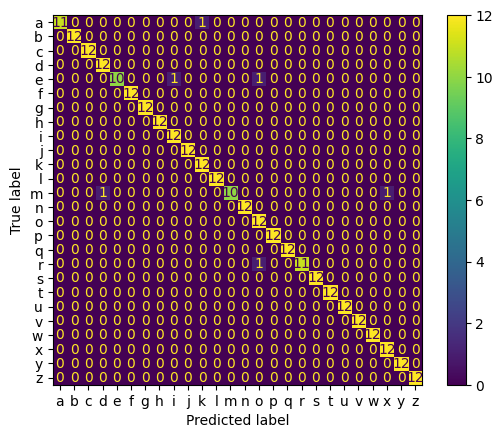

In [7]:
print(f"{classification_report(y_test, preds_test)}\n")

cm = ConfusionMatrixDisplay.from_predictions(y_test, preds_test)
cm.figure_.savefig("../docs/confusion_matrix_svm.png")